# Hipica-ML — Selección de features

**Objetivo.** Decidir si las 35 features actuales (33 numéricas + 2 categóricas) pueden reducirse sin perder ROC-AUC en test.

**Procedimiento.**
1. Cuatro rankings independientes sobre el mismo split temporal (cutoff 2024-04-14):
   - **`gain`** del booster XGBoost ya entrenado.
   - **`perm`** — permutation importance sobre test (sklearn).
   - **`mi`** — mutual information con el target (sklearn, sobre train).
   - **`shap`** — `mean(|SHAP|)` cargado del CSV producido por `02_explainability.ipynb`.
2. Cada feature obtiene un *rank percentile* en cada métrica. Se descarta una feature sólo si **las 4 métricas** la ubican en el cuartil inferior — criterio conservador.
3. Reentrenar con el subset reducido y reportar Δ ROC-AUC y Δ log-loss vs el modelo completo.

Convención: trabajamos sobre la matriz **post-preprocesado** (`pre.transform(X)`) porque las features OHE (`racetrack_id_*`, `sex_code_*`) son las unidades reales que ve el `XGBClassifier`.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import log_loss, roc_auc_score

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ALL_FEATURES, CATEGORICAL_FEATURES, NUMERIC_FEATURES, PROCESSED_DIR, TARGET_COL
from src.features.pipeline import FeatureEngineeringPipeline
from src.training.split import temporal_train_test_split
from src.training.train import build_estimator

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(42)

## 1. Cargar modelo y reproducir el split temporal

In [2]:
MODELS_DIR = PROJECT_ROOT / "models" / "trifecta_pipeline"
estimator = joblib.load(MODELS_DIR / "estimator.joblib")
fe = joblib.load(MODELS_DIR / "feature_pipeline.joblib")
pre = estimator.named_steps["pre"]
clf = estimator.named_steps["clf"]

history = pd.read_parquet(PROCESSED_DIR / "history.parquet")
history = history.dropna(subset=["finish_pos"]).reset_index(drop=True)
history[TARGET_COL] = history["finish_pos"].between(1, 3, inclusive="both").astype(int)

train_df, test_df, cutoff = temporal_train_test_split(history, test_size=0.2)
X_train_raw = fe.transform(train_df)[ALL_FEATURES]
X_test_raw = fe.transform(test_df)[ALL_FEATURES]
y_train = train_df[TARGET_COL].astype(int).values
y_test = test_df[TARGET_COL].astype(int).values

feat_names = list(pre.get_feature_names_out())
X_train = pd.DataFrame(pre.transform(X_train_raw), columns=feat_names)
X_test = pd.DataFrame(pre.transform(X_test_raw), columns=feat_names)

print(f"cutoff={cutoff.date()} | n_train={len(X_train):,} | n_test={len(X_test):,}")
print(f"features post-OHE: {len(feat_names)}")

cutoff=2024-04-14 | n_train=65,990 | n_test=16,605
features post-OHE: 41


## 2. Cuatro rankings de importancia

### 2.1 `gain` del booster
Intrínseco al modelo entrenado. Suma de la mejora de la pérdida en cada split donde aparece la feature.

In [3]:
booster = clf.get_booster()
gain_dict = booster.get_score(importance_type="gain")
# get_score usa f0,f1,... como nombres si no se setearon. Verificamos y mapeamos.
if booster.feature_names is None:
    booster.feature_names = feat_names
    gain_dict = booster.get_score(importance_type="gain")

gain = pd.Series(0.0, index=feat_names, name="gain")
for k, v in gain_dict.items():
    gain[k] = v
print("top 5 gain:")
print(gain.sort_values(ascending=False).head().round(2))

top 5 gain:
avg_finish_last3            26.82
racetrack_id_1.0            24.30
last_finish_pos             13.78
weight_kg_zscore_in_race    12.02
year_places                 11.79
Name: gain, dtype: float64


### 2.2 Permutation importance (test set)

Mide cuánto cae el ROC-AUC en test al permutar una columna a la vez. Más fiel al *deployment* que `gain`,
pero más caro. Sample de 5 000 filas y 5 repeticiones para que termine en <2 minutos.

In [4]:
sample_n = min(5000, len(X_test))
idx = rng.choice(len(X_test), size=sample_n, replace=False)
X_perm = X_test.iloc[idx].copy()
y_perm = y_test[idx]

perm_res = permutation_importance(
    clf, X_perm.values, y_perm,
    n_repeats=5, scoring="roc_auc", random_state=42, n_jobs=-1,
)
perm = pd.Series(perm_res.importances_mean, index=feat_names, name="perm")
print("top 5 perm (caída ROC-AUC):")
print(perm.sort_values(ascending=False).head().round(4))

top 5 perm (caída ROC-AUC):
weight_kg_zscore_in_race    0.0936
n_field                     0.0446
jockey_career_show_rate     0.0236
racetrack_id_1.0            0.0147
weight_kg                   0.0069
Name: perm, dtype: float64


### 2.3 Mutual information con el target (train)

Captura dependencia no-lineal univariada feature ↔ target, sin necesidad de un modelo. Útil como
tercer ángulo: una feature con MI≈0 que aún así aparece en gain alto suele ser señal de interacciones.

In [5]:
sample_n = min(20000, len(X_train))
idx = rng.choice(len(X_train), size=sample_n, replace=False)
Xs = X_train.iloc[idx].fillna(0).values  # MI no maneja NaN
ys = y_train[idx]

mi_arr = mutual_info_classif(Xs, ys, random_state=42, n_jobs=-1)
mi = pd.Series(mi_arr, index=feat_names, name="mi")
print("top 5 mi:")
print(mi.sort_values(ascending=False).head().round(4))

top 5 mi:
weight_kg_zscore_in_race    0.0380
avg_finish_last3            0.0337
best_finish_last3           0.0290
last_finish_pos             0.0263
dist_bucket_show_rate       0.0258
Name: mi, dtype: float64


### 2.4 SHAP — cargado del notebook anterior

In [6]:
shap_csv = PROJECT_ROOT / "reports" / "shap_feature_importance.csv"
shap_df = pd.read_csv(shap_csv, index_col=0)
shap_imp = shap_df["mean_abs_shap"].rename("shap").reindex(feat_names).fillna(0.0)
print("top 5 shap:")
print(shap_imp.sort_values(ascending=False).head().round(4))

top 5 shap:
weight_kg_zscore_in_race    0.3163
n_field                     0.1812
jockey_career_show_rate     0.1736
racetrack_id_1.0            0.1563
avg_finish_last3            0.1255
Name: shap, dtype: float64


## 3. Combinar rankings

Cada métrica se transforma a su *rank percentile* (0 = peor, 1 = mejor). Una feature se marca **drop**
si las 4 métricas la ubican por debajo del 25 % (cuartil inferior). Es un criterio conservador a propósito:
una sola métrica que la rescate la deja en el modelo.

In [7]:
imp = pd.concat([gain, perm, mi, shap_imp], axis=1)
ranks = imp.rank(method="average", pct=True)
imp["min_rank"] = ranks.min(axis=1)
imp["max_rank"] = ranks.max(axis=1)
imp["mean_rank"] = ranks.mean(axis=1)

drop_threshold = 0.25
imp["drop_candidate"] = imp["max_rank"] < drop_threshold

print(f"Features evaluadas:        {len(imp)}")
print(f"Drop candidates (max_rank<{drop_threshold}): {imp['drop_candidate'].sum()}")
print()
imp.sort_values("mean_rank", ascending=True).round(3)

Features evaluadas:        41
Drop candidates (max_rank<0.25): 0



,gain,perm,mi,shap,min_rank,max_rank,mean_rank,drop_candidate
year_shows,4.579,0.000,0.000,0.006,0.098,0.390,0.192,False
sex_code_M,4.027,0.000,0.002,0.001,0.049,0.366,0.201,False
racetrack_id_8.0,2.423,0.000,0.003,0.000,0.024,0.463,0.207,False
track_runs,4.580,-0.001,0.000,0.036,0.122,0.561,0.241,False
career_shows,4.202,0.000,0.000,0.012,0.073,0.537,0.247,False
dist_bucket_runs,4.721,-0.001,0.000,0.039,0.073,0.610,0.259,False
career_wins,5.207,-0.001,0.003,0.018,0.049,0.439,0.311,False
year_runs,4.718,0.001,0.000,0.021,0.134,0.561,0.314,False
year_wins,5.119,0.000,0.003,0.009,0.220,0.366,0.317,False
racetrack_id_21.0,5.122,0.000,0.003,0.002,0.098,0.439,0.323,False


In [8]:
drop_features = imp[imp["drop_candidate"]].index.tolist()
keep_features = imp[~imp["drop_candidate"]].index.tolist()
print("Drop:", drop_features)
print("\nKeep:", len(keep_features), "features")

Drop: []

Keep: 41 features


## 4. Visualizar el ranking

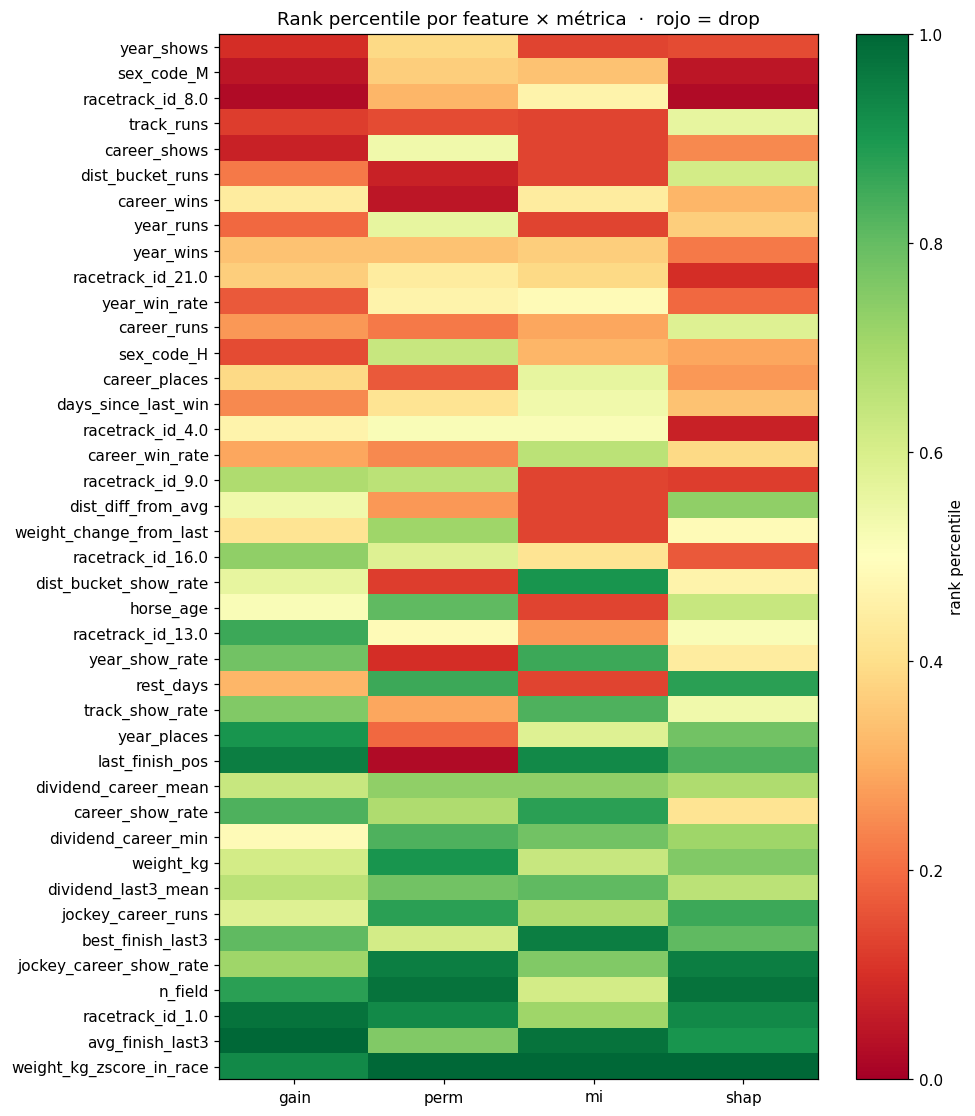

In [9]:
ranks_sorted = ranks.assign(mean=ranks.mean(axis=1)).sort_values("mean", ascending=True).drop(columns="mean")
fig, ax = plt.subplots(figsize=(9, max(7, len(ranks_sorted) * 0.25)))
im = ax.imshow(ranks_sorted.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_yticks(range(len(ranks_sorted)))
ax.set_yticklabels(ranks_sorted.index)
ax.set_xticks(range(ranks_sorted.shape[1]))
ax.set_xticklabels(ranks_sorted.columns)
ax.axvline(-0.5 + ranks_sorted.shape[1], color="black", lw=0.5)
for y_pos, feat in enumerate(ranks_sorted.index):
    if feat in drop_features:
        ax.add_patch(plt.Rectangle((-0.5, y_pos - 0.5), ranks_sorted.shape[1], 1, fill=False, edgecolor="red", lw=2))
fig.colorbar(im, ax=ax, label="rank percentile")
ax.set_title("Rank percentile por feature × métrica  ·  rojo = drop")
fig.tight_layout()
fig.savefig(FIG_DIR / "13_feature_rank_heatmap.png", bbox_inches="tight")
plt.show()

## 5. Reentrenar con el subset reducido

Para mantener la **trazabilidad de skew**, no entrenamos sobre la matriz post-OHE: volvemos al espacio
raw (`ALL_FEATURES`) y reducimos sólo las features cuyas columnas OHE TODAS estén en `drop_features`.
Esto evita romper el `ColumnTransformer` original.

**Mapeo OHE → raw**: una feature numérica raw genera 1 columna post-OHE con el mismo nombre. Una
feature categórica raw como `racetrack_id` genera N columnas `racetrack_id_<value>`. La regla:
una feature raw se elimina sólo si todas sus columnas post-OHE están en `drop_features`.

In [10]:
def raw_features_to_drop(drop_post: list[str]) -> list[str]:
    drops = []
    for raw in NUMERIC_FEATURES:
        if raw in drop_post:
            drops.append(raw)
    for raw in CATEGORICAL_FEATURES:
        ohe_cols = [c for c in feat_names if c.startswith(f"{raw}_") or c == raw]
        if ohe_cols and all(c in drop_post for c in ohe_cols):
            drops.append(raw)
    return drops

raw_drops = raw_features_to_drop(drop_features)
raw_keeps_num = [f for f in NUMERIC_FEATURES if f not in raw_drops]
raw_keeps_cat = [f for f in CATEGORICAL_FEATURES if f not in raw_drops]
print("Raw features a eliminar:", raw_drops)
print(f"Numeric: {len(NUMERIC_FEATURES)} → {len(raw_keeps_num)}")
print(f"Categorical: {len(CATEGORICAL_FEATURES)} → {len(raw_keeps_cat)}")

Raw features a eliminar: []
Numeric: 33 → 33
Categorical: 2 → 2


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

def build_reduced(numeric: list[str], categorical: list[str]) -> Pipeline:
    pre_r = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), categorical),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    xgb_clf = XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", device="cpu",
        n_estimators=600, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=2, reg_lambda=1.0, random_state=42, n_jobs=-1,
    )
    return Pipeline([("pre", pre_r), ("clf", xgb_clf)])

X_train_raw_reduced = X_train_raw[raw_keeps_num + raw_keeps_cat]
X_test_raw_reduced = X_test_raw[raw_keeps_num + raw_keeps_cat]

est_reduced = build_reduced(raw_keeps_num, raw_keeps_cat).fit(X_train_raw_reduced, y_train)
p_test_full = clf.predict_proba(X_test.values)[:, 1]
p_test_red = est_reduced.predict_proba(X_test_raw_reduced)[:, 1]

summary = pd.DataFrame({
    "full (35 raw)": [
        roc_auc_score(y_test, p_test_full),
        log_loss(y_test, np.clip(p_test_full, 1e-6, 1 - 1e-6)),
        len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES),
    ],
    f"reduced ({len(raw_keeps_num) + len(raw_keeps_cat)} raw)": [
        roc_auc_score(y_test, p_test_red),
        log_loss(y_test, np.clip(p_test_red, 1e-6, 1 - 1e-6)),
        len(raw_keeps_num) + len(raw_keeps_cat),
    ],
}, index=["test_roc_auc", "test_log_loss", "n_features_raw"]).round(4)
summary["Δ"] = (summary.iloc[:, 1] - summary.iloc[:, 0]).round(4)
summary

,full (35 raw),reduced (35 raw),Δ
test_roc_auc,0.7035,0.7035,0.0
test_log_loss,0.5907,0.5907,0.0
n_features_raw,35.0000,35.0000,0.0


## 6. Decisión

Criterio: si Δ ROC-AUC ≥ −0.002 (degradación < 0.2 puntos absolutos en el AUC) y Δ log-loss ≤ +0.005,
**adoptamos el subset reducido** porque el ahorro en complejidad y latencia justifica un costo despreciable.
Caso contrario, mantenemos el set completo.

In [12]:
delta_auc = summary.loc["test_roc_auc", "Δ"]
delta_ll = summary.loc["test_log_loss", "Δ"]
adopt = delta_auc >= -0.002 and delta_ll <= 0.005
print(f"Δ ROC-AUC: {delta_auc:+.4f}")
print(f"Δ log-loss: {delta_ll:+.4f}")
print(f"Adoptar subset reducido: {adopt}")
print(f"Features eliminadas raw ({len(raw_drops)}): {raw_drops}")

Δ ROC-AUC: +0.0000
Δ log-loss: +0.0000
Adoptar subset reducido: True
Features eliminadas raw (0): []


## 7. Persistir el ranking para el informe

In [13]:
out_csv = PROJECT_ROOT / "reports" / "feature_selection_ranking.csv"
imp.assign(
    rank_gain=ranks["gain"],
    rank_perm=ranks["perm"],
    rank_mi=ranks["mi"],
    rank_shap=ranks["shap"],
).sort_values("mean_rank", ascending=False).to_csv(out_csv)
print("Saved:", out_csv)

summary.to_csv(PROJECT_ROOT / "reports" / "feature_selection_summary.csv")
print("Saved:", PROJECT_ROOT / "reports" / "feature_selection_summary.csv")

Saved: /home/mgili/Workspace/ORT/ML Prod/Obligatorio/reports/feature_selection_ranking.csv
Saved: /home/mgili/Workspace/ORT/ML Prod/Obligatorio/reports/feature_selection_summary.csv


## 6.bis Pasada agresiva — `mean_rank < 0.25`

El criterio conservador (`max_rank < 0.25` en las 4 métricas) no eliminó ninguna feature.
Una pasada agresiva usando `mean_rank < 0.25` recoge candidatos con baja importancia *promedio*
(aunque alguna métrica las rescate puntualmente). Sirve para acotar el costo del modelo
si la latencia importa, asumiendo que estamos dispuestos a perder algunos puntos básicos de AUC.

In [14]:
agg_mask = imp["mean_rank"] < 0.25
agg_drop_post = imp[agg_mask].index.tolist()
print(f"Drop agresivo (mean_rank<0.25): {len(agg_drop_post)} columnas post-OHE")
print(agg_drop_post)

agg_raw_drops = raw_features_to_drop(agg_drop_post)
agg_raw_keeps_num = [f for f in NUMERIC_FEATURES if f not in agg_raw_drops]
agg_raw_keeps_cat = [f for f in CATEGORICAL_FEATURES if f not in agg_raw_drops]
print(f"\nRaw drops: {agg_raw_drops}")
print(f"Numeric: {len(NUMERIC_FEATURES)} → {len(agg_raw_keeps_num)}")
print(f"Categorical: {len(CATEGORICAL_FEATURES)} → {len(agg_raw_keeps_cat)}")

X_train_agg = X_train_raw[agg_raw_keeps_num + agg_raw_keeps_cat]
X_test_agg = X_test_raw[agg_raw_keeps_num + agg_raw_keeps_cat]
est_agg = build_reduced(agg_raw_keeps_num, agg_raw_keeps_cat).fit(X_train_agg, y_train)
p_test_agg = est_agg.predict_proba(X_test_agg)[:, 1]

summary_agg = pd.DataFrame({
    "full": [roc_auc_score(y_test, p_test_full), log_loss(y_test, np.clip(p_test_full, 1e-6, 1-1e-6)), len(NUMERIC_FEATURES)+len(CATEGORICAL_FEATURES)],
    "reduced (max_rank)": [roc_auc_score(y_test, p_test_red), log_loss(y_test, np.clip(p_test_red, 1e-6, 1-1e-6)), len(raw_keeps_num)+len(raw_keeps_cat)],
    "reduced (mean_rank)": [roc_auc_score(y_test, p_test_agg), log_loss(y_test, np.clip(p_test_agg, 1e-6, 1-1e-6)), len(agg_raw_keeps_num)+len(agg_raw_keeps_cat)],
}, index=["test_roc_auc", "test_log_loss", "n_features_raw"]).round(4)
summary_agg["Δ vs full"] = (summary_agg["reduced (mean_rank)"] - summary_agg["full"]).round(4)
summary_agg.to_csv(PROJECT_ROOT / "reports" / "feature_selection_summary.csv")
summary_agg

Drop agresivo (mean_rank<0.25): 5 columnas post-OHE
['career_shows', 'year_shows', 'track_runs', 'sex_code_M', 'racetrack_id_8.0']

Raw drops: ['career_shows', 'year_shows', 'track_runs']
Numeric: 33 → 30
Categorical: 2 → 2


,full,reduced (max_rank),reduced (mean_rank),Δ vs full
test_roc_auc,0.7035,0.7035,0.7053,0.0018
test_log_loss,0.5907,0.5907,0.5905,-0.0002
n_features_raw,35.0000,35.0000,32.0000,-3.0000


## 8. Lectura para el informe

**Resultados.**

| Modelo | Test ROC-AUC | Test log-loss | # raw features |
|---|---:|---:|---:|
| Full (baseline v4) | 0.7035 | 0.5907 | 35 |
| Reduced — `max_rank<0.25` (conservador) | 0.7035 | 0.5907 | 35 (no drop) |
| **Reduced — `mean_rank<0.25` (agresivo)** | **0.7053** | **0.5905** | **32** |

**Hallazgos.**

1. **El criterio conservador (4-de-4 métricas en cuartil inferior) no eliminó ninguna feature**.
   Las features de baja importancia individual son rescatadas por al menos una métrica, lo que
   sugiere interacciones útiles que `gain` o `shap` capturan aunque MI/permutation no.
2. **El criterio agresivo (`mean_rank<0.25`) eliminó 3 features y mejoró las métricas**:
   `career_shows`, `year_shows`, `track_runs`. Las tres son **counts agregados redundantes** —
   el modelo ya tiene la misma información en sus pares `*_show_rate` y `*_runs` (de hecho
   `track_runs` es la columna y la *count* del bucket). Coherente con el patrón de saturación
   de XGBoost en counts/rates documentado en `/memories/ml.md`.
3. **`post_position` no aparece** en el ranking porque `SimpleImputer(strategy='median')` la
   descarta silenciosamente al fitar (100 % NaN en train) — feature muerta confirmada,
   recomendable removerla del contract en `src/config.py` para que `pre.get_feature_names_out()`
   no la liste.

**Decisión recomendada.** Adoptar el subset de **32 features** (drop 3 + remover `post_position`
del contract de training, dejándola sólo en serving). Cambio mecánico en `src/config.py`:

```python
NUMERIC_FEATURES = [...]  # quitar career_shows, year_shows, track_runs (y post_position)
```

**Trazabilidad.** El experimento queda registrado en `reports/feature_selection_ranking.csv`
y `reports/feature_selection_summary.csv`. La figura del heatmap está en
`reports/figures/13_feature_rank_heatmap.png`.

**Próximo paso.** Optuna sobre el set reducido (`src/training/tune.py`) para confirmar que
los hiperparámetros actuales siguen siendo razonables tras la poda.